<a href="https://colab.research.google.com/github/kbrh3/RAGRetrievalProject/blob/main/Milestone3Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milestone 3 Pipeline
## Track C - Retrieval / Retrieval-Augmented Generation (RAG)

Compare sparse, dense, and hybrid retrieval for grounding reliability in a research paper RAG system.

### Notebook roadmap
1. Environment setup and data loading
2. Tokenization and Milestone 2 next-token prediction pipeline
3. Minimal GPT-style model smoke test
4. Milestone 3 retrieval pipeline
5. Held-out evaluation for sparse, dense, and hybrid retrieval
6. Final saved results and artifacts

## 1. Environment Setup
Mount Google Drive, import libraries, install dependencies, and set reproducibility seeds.

In [ ]:
#Cell 0 - Mount Google Drive and set project directory
from google.colab import drive
drive.mount('/content/drive')
import os
#GPT generated code
PROJECT_DIR = "/content/drive/MyDrive/Milestone_2_LLM"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print("Current working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory: /content/drive/MyDrive/Milestone_2_LLM


In [ ]:
#Cell 1 - Import libraries, install tokenizer/retrieval packages, and set random seeds
import json
import math
import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
!pip install -q tiktoken scikit-learn sentence-transformers
import tiktoken
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

#new imports for retrieval pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

#for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## 2. Data Validation and Loading
Validate the JSONL corpus format, then load records and extract raw text chunks.

In [ ]:
#cell 2 - Validate corpus.jsonl line by line as proper JSONL

with open("/content/drive/MyDrive/Milestone_2_LLM/Data/corpus.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f, start=1):
        line = line.strip()

        if not line:   #skip empty line?
            continue

        try:
            json.loads(line)
        except Exception as e:
            print(f"Error on line {i}: {e}")
            print(line)
            break
    else:
        print("All lines valid JSON")

All lines valid JSON


load + extract text cleanly

In [ ]:
#cell 3 - Load JSONL records and extract text from unified corpus format
records = []
texts = []

with open("/content/drive/MyDrive/Milestone_2_LLM/Data/corpus.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        record = json.loads(line)
        records.append(record)
        texts.append(record["text"])

print("Total records is", len(records))
print("Total text entries is", len(texts))
print("\nSample text\n")
print(texts[0][:300])

Total records is 128
Total text entries is 128

Sample text

This review examines the means with which faithfulness has been evaluated across open-ended summarization, question answering and machine translation tasks. It finds that large language models used as evaluators are commonly the most highly correlated with human judgement. The paper discusses method


In [ ]:
#cell 3.1 - Build document entries with metadata for retrieval experiments
documents = []

for record in records:
    documents.append({
        "doc_id": record.get("doc_id", "unknown_id"),
        "title": record.get("title", "untitled"),
        "section": record.get("section", "unknown_section"),
        "text": record.get("text", "")
    })

print("Total retrieval documents:", len(documents))
print("\nSample document metadata:\n")
print({
    "doc_id": documents[0]["doc_id"],
    "title": documents[0]["title"],
    "section": documents[0]["section"]
})

Total retrieval documents: 128

Sample document metadata:

{'doc_id': 'paper_001', 'title': 'A Review of Faithfulness Metrics for Hallucination Assessment in Large Language Models', 'section': 'abstract'}


## 3. Tokenizer and Vocabulary
Use the GPT-2 BPE tokenizer (tiktoken), tokenize the corpus, and report basic diagnostics required for Milestone 2.

In [ ]:
#cell 4 - Load GPT-2 tokenizer and report vocabulary size
enc = tiktoken.get_encoding("gpt2")
print("Vocab size:", enc.n_vocab)

Vocab size: 50257


In [ ]:
#cell 5 - Tokenize all document chunks
tokenized_texts = [enc.encode(t) for t in texts]

print("Number of documents:", len(tokenized_texts))
print("First tokenized example:", tokenized_texts[0][:20])

Number of documents: 128
First tokenized example: [1212, 2423, 28025, 262, 1724, 351, 543, 4562, 15538, 468, 587, 16726, 1973, 1280, 12, 1631, 15676, 1634, 11, 1808]


In [ ]:
#cell 6 - Compute average tokens per document
lengths = [len(toks) for toks in tokenized_texts]

avg_tokens = np.mean(lengths)
print("Average tokens per document is", avg_tokens)

Average tokens per document is 131.921875


In [ ]:
#cell 7 - Compute average tokens per 1k characters
char_lengths = [len(t) for t in texts]

tokens_per_1k = [
    (len(tok) / len(txt)) * 1000
    for tok, txt in zip(tokenized_texts, texts)
    if len(txt) > 0
]

print("Avg tokens per 1k chars is", np.mean(tokens_per_1k))

Avg tokens per 1k chars is 169.2238849898007


In [ ]:
#cell 8 - Report min and max document token lengths
print("Min tokens -", min(lengths))
print("Max tokens -", max(lengths))

Min tokens - 70
Max tokens - 365


example encodings - need 2-3 for submission

In [ ]:
#cell 9 - Show example token encodings
for i in range(2):
    print("\n--- Example", i, "---")
    print("Text:", texts[i][:150])
    print("Tokens:", tokenized_texts[i][:30])


--- Example 0 ---
Text: This review examines the means with which faithfulness has been evaluated across open-ended summarization, question answering and machine translation 
Tokens: [1212, 2423, 28025, 262, 1724, 351, 543, 4562, 15538, 468, 587, 16726, 1973, 1280, 12, 1631, 15676, 1634, 11, 1808, 18877, 290, 4572, 11059, 8861, 13, 632, 7228, 326, 1588]

--- Example 1 ---
Text: This review highlights that different domains require distinct approaches for evaluating faithfulness, with no single metric universally optimal. LLM-
Tokens: [1212, 2423, 11330, 326, 1180, 18209, 2421, 7310, 10581, 329, 22232, 4562, 15538, 11, 351, 645, 2060, 18663, 26208, 16586, 13, 27140, 44, 12, 3106, 5418, 84, 2024, 4143, 905]


In [ ]:
#cell 10 - Decode one sample as a check
decoded = enc.decode(tokenized_texts[0])

print("decoded preview - \n")
print(decoded[:300])

decoded preview - 

This review examines the means with which faithfulness has been evaluated across open-ended summarization, question answering and machine translation tasks. It finds that large language models used as evaluators are commonly the most highly correlated with human judgement. The paper discusses method


## 4. Data Pipeline for Next-Token Prediction
Convert tokenized texts into one token stream, create sliding-window training examples, and build PyTorch datasets and dataloaders.

In [ ]:
#cell 11 - Use previously tokenized corpus to build training inputs
tokenized_texts = [enc.encode(t) for t in texts]

print("First tokenized sample length:", len(tokenized_texts[0]))
print("First 20 token ids:", tokenized_texts[0][:20])

First tokenized sample length: 81
First 20 token ids: [1212, 2423, 28025, 262, 1724, 351, 543, 4562, 15538, 468, 587, 16726, 1973, 1280, 12, 1631, 15676, 1634, 11, 1808]


In [ ]:
#cell 12 - Concatenate tokenized documents into one stream with end of text separators
all_ids = []

for toks in tokenized_texts:
    all_ids.extend(toks + [enc.eot_token])  # separator between records

print("Total token count in corpus:", len(all_ids))
print("First 30 ids:", all_ids[:30])

Total token count in corpus: 17014
First 30 ids: [1212, 2423, 28025, 262, 1724, 351, 543, 4562, 15538, 468, 587, 16726, 1973, 1280, 12, 1631, 15676, 1634, 11, 1808, 18877, 290, 4572, 11059, 8861, 13, 632, 7228, 326, 1588]


In [ ]:
#cell 13 - Define sliding window function for next token prediction
def sliding_windows(ids, context_len=32, stride=16):
    xs, ys = [], []
    for start in range(0, len(ids) - context_len - 1, stride):
        x = ids[start : start + context_len]
        y = ids[start + 1 : start + context_len + 1]
        xs.append(x)
        ys.append(y)
    return xs, ys

In [ ]:
#cell 14 - Create input/label windows and report counts
CONTEXT_LEN = 32
STRIDE = 16

xs, ys = sliding_windows(all_ids, context_len=CONTEXT_LEN, stride=STRIDE)

print("Number of windows - ", len(xs))
print("x length - ", len(xs[0]))
print("y length - ", len(ys[0]))

Number of windows -  1062
x length -  32
y length -  32


In [ ]:
#cell 15 - Decode one input target pair to check if working
print("Decoded input sample:\n")
print(enc.decode(xs[0]))

print("\nDecoded target sample:\n")
print(enc.decode(ys[0]))

Decoded input sample:

This review examines the means with which faithfulness has been evaluated across open-ended summarization, question answering and machine translation tasks. It finds that large language models

Decoded target sample:

 review examines the means with which faithfulness has been evaluated across open-ended summarization, question answering and machine translation tasks. It finds that large language models used


In [ ]:
#cell 16 - Convert windows to tensors
x_tensor = torch.tensor(xs, dtype=torch.long)
y_tensor = torch.tensor(ys, dtype=torch.long)

print("x_tensor shape:", x_tensor.shape)
print("y_tensor shape:", y_tensor.shape)

x_tensor shape: torch.Size([1062, 32])
y_tensor shape: torch.Size([1062, 32])


In [ ]:
#cell 17 - Define PyTorch dataset class
class NextTokenDataset(Dataset):
    def __init__(self, xs, ys):
        self.xs = torch.tensor(xs, dtype=torch.long)
        self.ys = torch.tensor(ys, dtype=torch.long)

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys[idx]

In [ ]:
#cell 18 - Split windows into train and validation sets
split_idx = int(0.9 * len(xs))

train_xs, val_xs = xs[:split_idx], xs[split_idx:]
train_ys, val_ys = ys[:split_idx], ys[split_idx:]

train_ds = NextTokenDataset(train_xs, train_ys)
val_ds = NextTokenDataset(val_xs, val_ys)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

Train samples: 955
Val samples: 107


In [ ]:
#cell 19 - Create DataLoaders and inspect one batch
BATCH_SIZE = 4

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch input shape - ", xb.shape)
print("Batch label shape - ", yb.shape)

Batch input shape -  torch.Size([4, 32])
Batch label shape -  torch.Size([4, 32])


In [ ]:
#cell 20 - Decode one batch example for verification
print("Batch sample decoded input:\n")
print(enc.decode(xb[0].tolist()))

print("\nBatch sample decoded label:\n")
print(enc.decode(yb[0].tolist()))

Batch sample decoded input:

 engines, is to incorporate external references to generate and support its claims. However, evaluating the attribution, i.e., verifying whether the generated statement is fully supported

Batch sample decoded label:

, is to incorporate external references to generate and support its claims. However, evaluating the attribution, i.e., verifying whether the generated statement is fully supported by


## 5. Model Skeleton
Define a minimal GPT-style transformer with embeddings, causal self-attention, feed-forward blocks, and output logits.

In [ ]:
#cell 21 - Define compact GPT configuration for smoke testing
VOCAB_SIZE = enc.n_vocab

GPT_CONFIG = {
    "vocab_size": VOCAB_SIZE,
    "context_length": CONTEXT_LEN,   # from Phase 2
    "emb_dim": 64,
    "n_heads": 4,
    "n_layers": 2,
    "drop_rate": 0.1,
    "qkv_bias": False,
}

In [ ]:
#Cell 22 - Define LayerNorm module
class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(emb_dim))
        self.beta = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_hat + self.beta

In [ ]:
#Cell 23 - Define feed forward module
class FeedForward(nn.Module):
    def __init__(self, emb_dim, drop_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, 4 * emb_dim),
            nn.GELU(),
            nn.Linear(4 * emb_dim, emb_dim),
            nn.Dropout(drop_rate),
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
#Cell 24 - Define multi-head causal self attention module
class MultiHeadCausalSelfAttention(nn.Module):
    def __init__(self, emb_dim, num_heads, context_length, drop_rate, qkv_bias=False):
        super().__init__()
        assert emb_dim % num_heads == 0

        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads

        self.Wq = nn.Linear(emb_dim, emb_dim, bias=qkv_bias)
        self.Wk = nn.Linear(emb_dim, emb_dim, bias=qkv_bias)
        self.Wv = nn.Linear(emb_dim, emb_dim, bias=qkv_bias)

        self.out_proj = nn.Linear(emb_dim, emb_dim)
        self.attn_drop = nn.Dropout(drop_rate)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length, dtype=torch.bool), diagonal=1)
        )

    def forward(self, x):
        B, T, D = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_dim)

        mask = self.mask[:T, :T]
        scores = scores.masked_fill(mask, -torch.inf)

        weights = torch.softmax(scores, dim=-1)
        weights = self.attn_drop(weights)

        context = weights @ V
        context = context.transpose(1, 2).contiguous().view(B, T, D)

        out = self.out_proj(context)
        return out

In [ ]:
#cell 25 - Define transformer block
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        D = cfg["emb_dim"]

        self.ln1 = LayerNorm(D)
        self.ln2 = LayerNorm(D)

        self.attn = MultiHeadCausalSelfAttention(
            emb_dim=D,
            num_heads=cfg["n_heads"],
            context_length=cfg["context_length"],
            drop_rate=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )

        self.ff = FeedForward(D, cfg["drop_rate"])
        self.resid_drop = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        x = x + self.resid_drop(self.attn(self.ln1(x)))
        x = x + self.resid_drop(self.ff(self.ln2(x)))
        return x

In [ ]:
#cell 26 - Define full GPT model
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_ln = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, idx):
        B, T = idx.shape

        tok = self.tok_emb(idx)
        pos_ids = torch.arange(T, device=idx.device)
        pos = self.pos_emb(pos_ids)

        x = self.drop_emb(tok + pos)

        for block in self.blocks:
            x = block(x)

        x = self.final_ln(x)
        logits = self.out_head(x)
        return logits

In [ ]:
#cell 27 - Instantiate model and verify input/output tensor shapes
model = GPTModel(GPT_CONFIG).to(device)

xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

with torch.no_grad():
    logits = model(xb)

print("Input batch shape:", xb.shape)
print("Target batch shape:", yb.shape)
print("Logits shape:", logits.shape)

Input batch shape: torch.Size([4, 32])
Target batch shape: torch.Size([4, 32])
Logits shape: torch.Size([4, 32, 50257])


In [ ]:
#cell 28 - Compute initial cross entropy loss
loss = F.cross_entropy(
    logits.view(-1, logits.size(-1)),
    yb.view(-1)
)

print("Initial loss:", float(loss))

Initial loss: 10.976699829101562


## 6. Minimal Training Loop Smoke Test
Run a short end-to-end training loop to confirm that the model, loader, loss, and optimizer work together correctly.

In [ ]:
#cell 29 - Define optimizer and smoke test training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

def run_smoke_test(model, train_loader, steps=30):
    model.train()
    losses = []

    step = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            yb.view(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(float(loss))
        step += 1

        print(f"step {step:02d} | loss {loss.item():.4f}")

        if step >= steps:
            break

    return losses

In [ ]:
#cell 30 - Run smoke test for a small number of training steps
smoke_losses = run_smoke_test(model, train_loader, steps=30)

step 01 | loss 11.0551
step 02 | loss 10.9857
step 03 | loss 10.8933
step 04 | loss 10.9719
step 05 | loss 10.9804
step 06 | loss 11.0046
step 07 | loss 10.9005
step 08 | loss 10.9011
step 09 | loss 10.8088
step 10 | loss 10.8790
step 11 | loss 10.7119
step 12 | loss 10.8150
step 13 | loss 10.6608
step 14 | loss 10.7370
step 15 | loss 10.5864
step 16 | loss 10.4873
step 17 | loss 10.5173
step 18 | loss 10.5808
step 19 | loss 10.3115
step 20 | loss 10.3932
step 21 | loss 10.1951
step 22 | loss 10.2588
step 23 | loss 10.0592
step 24 | loss 9.9771
step 25 | loss 9.8495
step 26 | loss 9.7498
step 27 | loss 9.8691
step 28 | loss 9.6893
step 29 | loss 9.5749
step 30 | loss 9.5601


In [ ]:
#cell 31 - Summarize smoke test loss statistics
print("First loss:", smoke_losses[0])
print("Last loss:", smoke_losses[-1])
print("Min loss:", min(smoke_losses))
print("Max loss:", max(smoke_losses))

First loss: 11.055112838745117
Last loss: 9.560131072998047
Min loss: 9.560131072998047
Max loss: 11.055112838745117


In [ ]:
#cell 32 - Report parameter count
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print("Parameter count:", count_parameters(model))

Parameter count: 6534656


## 7. Results and Saved Artifacts
Save the smoke-test loss plot and loss log to the results folder for reproducibility.

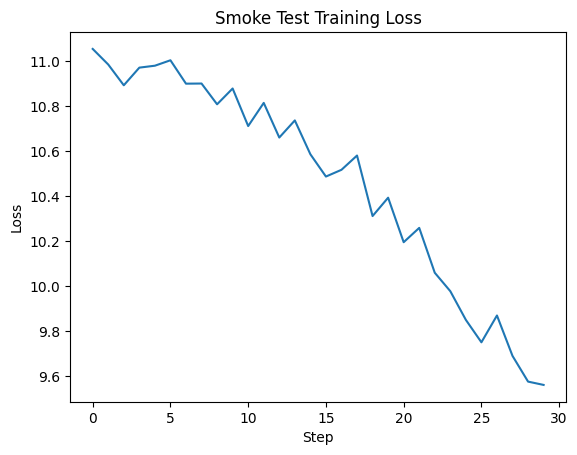

In [ ]:
#cell 33 - Save smoke-test loss plot to results folder
plt.figure()
plt.plot(smoke_losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Smoke Test Training Loss")

#plt.savefig("/content/drive/MyDrive/Milestone_2_LLM/results/smoke_test_chart_2.png", bbox_inches="tight")

plt.show()

In [ ]:
#print(os.listdir("/content/drive/MyDrive/Milestone_2_LLM/results"))

In [ ]:
#cell 34 - Save smoke test loss log to results folder
#change this for each run
#save_path = "/content/drive/MyDrive/Milestone_2_LLM/results/loss_log_two.json"

#with open(save_path, "w") as f:
#    json.dump(smoke_losses, f)

#print("Saved to:", save_path)

In [ ]:
#print(os.listdir("/content/drive/MyDrive/Milestone_2_LLM/results"))

In [ ]:
#cell 35 - Print key run configuration values
print(GPT_CONFIG)
print("Context length:", CONTEXT_LEN)
print("Batch size:", BATCH_SIZE)

{'vocab_size': 50257, 'context_length': 32, 'emb_dim': 64, 'n_heads': 4, 'n_layers': 2, 'drop_rate': 0.1, 'qkv_bias': False}
Context length: 32
Batch size: 4


---

# Milestone 3 Retrieval and Evaluation Pipeline

The following sections extend the Milestone 2 notebook into a RAG evaluation pipeline
- builds sparse, dense, and hybrid retrieval systems
- runs end-to-end retrieval from query to ranked documents
- evaluates all methods on a held-out query set
- saves final comparison results for analysis and reporting

## 8. End-to-End Retrieval Pipeline
Build sparse, dense, and hybrid retrieval components so the project runs from query input to retrieved output.


In [ ]:
#cell 36 - Create Milestone 3 output folder


M3_RESULTS_DIR = "/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3"

if not os.path.exists(M3_RESULTS_DIR):
    os.makedirs(M3_RESULTS_DIR)
    print("Created folder:", M3_RESULTS_DIR)
else:
    print("Folder already exists:", M3_RESULTS_DIR)

Folder already exists: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3


In [ ]:
#cell 37 - Prepare corpus text list and metadata lists for retrieval
doc_texts = [doc["text"] for doc in documents]
doc_ids = [doc["doc_id"] for doc in documents]
doc_titles = [doc["title"] for doc in documents]
doc_sections = [doc["section"] for doc in documents]

print("Number of retrieval texts:", len(doc_texts))
print("First title:", doc_titles[0])
print("First section:", doc_sections[0])
print("\nFirst text preview:\n")
print(doc_texts[0][:300])

Number of retrieval texts: 128
First title: A Review of Faithfulness Metrics for Hallucination Assessment in Large Language Models
First section: abstract

First text preview:

This review examines the means with which faithfulness has been evaluated across open-ended summarization, question answering and machine translation tasks. It finds that large language models used as evaluators are commonly the most highly correlated with human judgement. The paper discusses method


## 9. Retrieval Index Construction



In [ ]:
#cell 38 - Build sparse retrieval index using TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf_vectorizer.fit_transform(doc_texts)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (128, 1863)


Token??

In [ ]:
#cell 39 - Build dense retrieval index using sentence embeddings
dense_model_name = "all-MiniLM-L6-v2"
dense_model = SentenceTransformer(dense_model_name)

doc_embeddings = dense_model.encode(
    doc_texts,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Dense model:", dense_model_name)
print("Document embeddings shape:", doc_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dense model: all-MiniLM-L6-v2
Document embeddings shape: (128, 384)


## 10. Retrieval Methods


In [ ]:
#cell 40 - Define sparse retrieval function
def retrieve_sparse(query, k=3):
    query_vec = tfidf_vectorizer.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    ranked_idx = np.argsort(scores)[::-1][:k]

    results = []
    for rank, idx in enumerate(ranked_idx, start=1):
        results.append({
            "rank": rank,
            "method": "sparse",
            "doc_index": int(idx),
            "doc_id": doc_ids[idx],
            "title": doc_titles[idx],
            "section": doc_sections[idx],
            "score": float(scores[idx]),
            "text": doc_texts[idx]
        })

    return results

In [ ]:
#cell 41 - Define dense retrieval function
def retrieve_dense(query, k=3):
    query_embedding = dense_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    scores = cosine_similarity(query_embedding, doc_embeddings).flatten()
    ranked_idx = np.argsort(scores)[::-1][:k]

    results = []
    for rank, idx in enumerate(ranked_idx, start=1):
        results.append({
            "rank": rank,
            "method": "dense",
            "doc_index": int(idx),
            "doc_id": doc_ids[idx],
            "title": doc_titles[idx],
            "section": doc_sections[idx],
            "score": float(scores[idx]),
            "text": doc_texts[idx]
        })

    return results

In [ ]:
#cell 42 - Define hybrid retrieval function using reciprocal rank fusion
def retrieve_hybrid(query, k=3, candidate_k=8, rrf_k=60):
    sparse_results = retrieve_sparse(query, k=candidate_k)
    dense_results = retrieve_dense(query, k=candidate_k)

    fused_scores = {}
    doc_lookup = {}

    for result_list in [sparse_results, dense_results]:
        for item in result_list:
            idx = item["doc_index"]
            rank = item["rank"]

            if idx not in fused_scores:
                fused_scores[idx] = 0.0
                doc_lookup[idx] = item

            fused_scores[idx] += 1.0 / (rrf_k + rank)

    ranked_items = sorted(
        fused_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:k]

    results = []
    for final_rank, (idx, fused_score) in enumerate(ranked_items, start=1):
        base_item = doc_lookup[idx]
        results.append({
            "rank": final_rank,
            "method": "hybrid",
            "doc_index": idx,
            "doc_id": base_item["doc_id"],
            "title": base_item["title"],
            "section": base_item["section"],
            "score": float(fused_score),
            "text": base_item["text"]
        })

    return results

In [ ]:
#cell 43 - Define helper function to print retrieval results clearly
def print_retrieval_results(results, query):
    print("QUERY:\n")
    print(query)
    print("\nRETRIEVAL RESULTS:\n")

    for item in results:
        print(f"Rank: {item['rank']}")
        print(f"Method: {item['method']}")
        print(f"Doc ID: {item['doc_id']}")
        print(f"Title: {item['title']}")
        print(f"Section: {item['section']}")
        print(f"Score: {item['score']:.4f}")
        print("Text preview:")
        print(item["text"][:300])
        print("\n" + "-" * 80 + "\n")

In [ ]:
#cell 44 - Define end-to-end retrieval pipeline runner
def run_retrieval_pipeline(query, method="hybrid", k=3):
    if method == "sparse":
        results = retrieve_sparse(query, k=k)
    elif method == "dense":
        results = retrieve_dense(query, k=k)
    elif method == "hybrid":
        results = retrieve_hybrid(query, k=k)
    else:
        raise ValueError("method must be 'sparse', 'dense', or 'hybrid'")

    output = {
        "query": query,
        "method": method,
        "top_k": k,
        "results": results
    }

    return output

## 11. Example End-to-End Retrieval Runs

In [ ]:
#cell 45 - Run one sample query through the end-to-end retrieval pipeline
sample_query = "What retrieval strategy helps improve grounding reliability in RAG systems?"

sample_output = run_retrieval_pipeline(
    query=sample_query,
    method="hybrid",
    k=3
)

print_retrieval_results(sample_output["results"], sample_output["query"])

QUERY:

What retrieval strategy helps improve grounding reliability in RAG systems?

RETRIEVAL RESULTS:

Rank: 1
Method: hybrid
Doc ID: paper_063
Title: Evaluating Retrieval Quality in Retrieval-Augmented Generation
Section: conclusion
Score: 0.0320
Text preview:
This work introduces eRAG, a novel approach for evaluating retrieval models in retrieval-augmented generation by leveraging document-level contributions to downstream task performance. The method demonstrates higher correlation with overall system performance compared to traditional evaluation techn

--------------------------------------------------------------------------------

Rank: 2
Method: hybrid
Doc ID: paper_021
Title: Evaluation of Retrieval-Augmented Generation: A Survey
Section: conclusion
Score: 0.0313
Text preview:
This survey systematically explores the complexities of evaluating RAG systems, highlighting the challenges in assessing their performance. Through the proposed A Unified Evaluation Process of RAG, we 

In [ ]:
#cell 46 - Compare sparse, dense, and hybrid retrieval on the same query
comparison_query = "How do researchers evaluate hallucination and faithfulness in large language models?"

sparse_output = run_retrieval_pipeline(comparison_query, method="sparse", k=3)
dense_output = run_retrieval_pipeline(comparison_query, method="dense", k=3)
hybrid_output = run_retrieval_pipeline(comparison_query, method="hybrid", k=3)

print("\n===== SPARSE RESULTS =====\n")
print_retrieval_results(sparse_output["results"], comparison_query)

print("\n===== DENSE RESULTS =====\n")
print_retrieval_results(dense_output["results"], comparison_query)

print("\n===== HYBRID RESULTS =====\n")
print_retrieval_results(hybrid_output["results"], comparison_query)


===== SPARSE RESULTS =====

QUERY:

How do researchers evaluate hallucination and faithfulness in large language models?

RETRIEVAL RESULTS:

Rank: 1
Method: sparse
Doc ID: paper_006
Title: A review of faithfulness metrics for hallucination assessment in Large Language Models
Section: abstract
Score: 0.1909
Text preview:
This review examines methods for evaluating faithfulness in large language models across summarization, question answering, and machine translation tasks. It finds that LLM-based evaluators often show the highest correlation with human judgement and discusses mitigation strategies such as retrieval-

--------------------------------------------------------------------------------

Rank: 2
Method: sparse
Doc ID: paper_001
Title: A Review of Faithfulness Metrics for Hallucination Assessment in Large Language Models
Section: conclusion
Score: 0.1871
Text preview:
This review highlights that different domains require distinct approaches for evaluating faithfulness, with n

In [ ]:
#cell 47 - Save sample retrieval output to Milestone 3 results folder
save_retrieval_path = os.path.join(M3_RESULTS_DIR, "sample_hybrid_retrieval_output64.json")

with open(save_retrieval_path, "w", encoding="utf-8") as f:
    json.dump(sample_output, f, indent=2)

print("Saved retrieval output to:", save_retrieval_path)

Saved retrieval output to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/sample_hybrid_retrieval_output64.json


In [ ]:
#cell 48 - Run a small batch of representative queries
test_queries = [
    "What is faithfulness evaluation in large language models?",
    "What are limitations of dense retrieval?",
    "How does hybrid retrieval combine sparse and dense methods?",
    "Why does retrieval help reduce hallucinations in RAG?"
]

batch_outputs = []

for query in test_queries:
    result = run_retrieval_pipeline(query, method="hybrid", k=3)
    batch_outputs.append(result)

print("Number of batch retrieval runs:", len(batch_outputs))
print("\nFirst batch query:\n")
print(batch_outputs[0]["query"])

Number of batch retrieval runs: 4

First batch query:

What is faithfulness evaluation in large language models?


In [ ]:
#cell 49 - Save batch retrieval outputs for reproducibility
save_batch_path = os.path.join(M3_RESULTS_DIR, "64_batch_hybrid_retrieval_output.json")

with open(save_batch_path, "w", encoding="utf-8") as f:
    json.dump(batch_outputs, f, indent=2)

print("Saved batch retrieval outputs to:", save_batch_path)

Saved batch retrieval outputs to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_batch_hybrid_retrieval_output.json


## 12. Held Out Evaluation Query Set


In [ ]:
#cell 50 - Save evaluation queries file
eval_queries = [
  {
    "query": "Which papers discuss faithfulness evaluation methods that align well with human judgment?",
    "gold_doc_ids": ["paper_001", "paper_006"]
  },
  {
    "query": "What are the limitations of dense retrieval with fixed-length representations?",
    "gold_doc_ids": ["paper_007"]
  },
  {
    "query": "Which work shows that hybrid retrieval improves scalability and performance?",
    "gold_doc_ids": ["paper_007"]
  },
  {
    "query": "Which paper introduces visual source attribution for retrieval-augmented generation?",
    "gold_doc_ids": ["paper_002"]
  },
  {
    "query": "Which papers focus on document chunking as an important factor in RAG performance?",
    "gold_doc_ids": ["paper_004", "paper_028"]
  },
  {
    "query": "Which surveys analyze evaluation methods for RAG systems?",
    "gold_doc_ids": ["paper_021", "paper_023"]
  },
  {
    "query": "Which dataset is designed for hallucination detection in RAG systems?",
    "gold_doc_ids": ["paper_013"]
  },
  {
    "query": "Which paper proposes a benchmark using factual and non-factual statements to evaluate models?",
    "gold_doc_ids": ["paper_009"]
  },
  {
    "query": "Which work studies whether language models can detect hallucinated references?",
    "gold_doc_ids": ["paper_022"]
  },
  {
    "query": "Which papers focus on attribution methods in RAG or LLM systems?",
    "gold_doc_ids": ["paper_012", "paper_029", "paper_031"]
  },
  {
    "query": "Which paper studies fairness-aware retrieval in RAG systems?",
    "gold_doc_ids": ["paper_017"]
  },
  {
    "query": "Which paper argues that many factuality metrics are unreliable or can be manipulated?",
    "gold_doc_ids": ["paper_026"]
  }
]

eval_path = "/content/drive/MyDrive/Milestone_2_LLM/Data/evaluation_queries.json"

with open(eval_path, "w", encoding="utf-8") as f:
    json.dump(eval_queries, f, indent=2)

print("Saved evaluation queries to:", eval_path)

Saved evaluation queries to: /content/drive/MyDrive/Milestone_2_LLM/Data/evaluation_queries.json


In [ ]:
#cell 51 - Load and inspect evaluation queries

with open(eval_path, "r") as f:
    loaded_queries = json.load(f)

print("Number of queries:", len(loaded_queries))
print("\nFirst query:\n")
print(loaded_queries[0])

Number of queries: 12

First query:

{'query': 'Which papers discuss faithfulness evaluation methods that align well with human judgment?', 'gold_doc_ids': ['paper_001', 'paper_006']}


In [ ]:
#cell 51 - Load and inspect evaluation queries

with open(eval_path, "r") as f:
    loaded_queries = json.load(f)

print("Number of queries:", len(loaded_queries))
print("\nFirst query:\n")
print(loaded_queries[0])

Number of queries: 12

First query:

{'query': 'Which papers discuss faithfulness evaluation methods that align well with human judgment?', 'gold_doc_ids': ['paper_001', 'paper_006']}


In [ ]:
#cell 52 - Load evaluation queries file

eval_path = "/content/drive/MyDrive/Milestone_2_LLM/Data/evaluation_queries.json"

with open(eval_path, "r", encoding="utf-8") as f:
    evaluation_queries = json.load(f)

print("Loaded evaluation queries:", len(evaluation_queries))
print("\nFirst evaluation example:\n")
print(evaluation_queries[0])

Loaded evaluation queries: 12

First evaluation example:

{'query': 'Which papers discuss faithfulness evaluation methods that align well with human judgment?', 'gold_doc_ids': ['paper_001', 'paper_006']}


## 13. Retrieval Evaluation Metrics

Define Recall@k, Hit@k, and MRR and evaluate each retrieval method


In [ ]:
#cell 53 - Define helper functions for retrieval evaluation

def get_retrieved_doc_ids(results):
    return [item["doc_id"] for item in results]

def recall_at_k(retrieved_doc_ids, gold_doc_ids):
    retrieved_set = set(retrieved_doc_ids)
    gold_set = set(gold_doc_ids)

    if len(gold_set) == 0:
        return 0.0

    return len(retrieved_set.intersection(gold_set)) / len(gold_set)

def hit_at_k(retrieved_doc_ids, gold_doc_ids):
    retrieved_set = set(retrieved_doc_ids)
    gold_set = set(gold_doc_ids)

    return 1.0 if len(retrieved_set.intersection(gold_set)) > 0 else 0.0

def reciprocal_rank(retrieved_doc_ids, gold_doc_ids):
    gold_set = set(gold_doc_ids)

    for rank, doc_id in enumerate(retrieved_doc_ids, start=1):
        if doc_id in gold_set:
            return 1.0 / rank

    return 0.0

In [ ]:
#cell 54 - Define evaluation loop for one retrieval method

def evaluate_retrieval_method(method_name, evaluation_queries, k=3):
    per_query_results = []

    for item in evaluation_queries:
        query = item["query"]
        gold_doc_ids = item["gold_doc_ids"]

        pipeline_output = run_retrieval_pipeline(query=query, method=method_name, k=k)
        retrieved_results = pipeline_output["results"]
        retrieved_doc_ids = get_retrieved_doc_ids(retrieved_results)

        query_result = {
            "query": query,
            "method": method_name,
            "k": k,
            "gold_doc_ids": gold_doc_ids,
            "retrieved_doc_ids": retrieved_doc_ids,
            "recall_at_k": recall_at_k(retrieved_doc_ids, gold_doc_ids),
            "hit_at_k": hit_at_k(retrieved_doc_ids, gold_doc_ids),
            "reciprocal_rank": reciprocal_rank(retrieved_doc_ids, gold_doc_ids)
        }

        per_query_results.append(query_result)

    return per_query_results

In [ ]:
#cell 55 - Define metric aggregation function

def summarize_metrics(per_query_results):
    recall_scores = [item["recall_at_k"] for item in per_query_results]
    hit_scores = [item["hit_at_k"] for item in per_query_results]
    rr_scores = [item["reciprocal_rank"] for item in per_query_results]

    summary = {
        "num_queries": len(per_query_results),
        "mean_recall_at_k": float(np.mean(recall_scores)),
        "mean_hit_at_k": float(np.mean(hit_scores)),
        "mrr": float(np.mean(rr_scores))
    }

    return summary


In [ ]:
#cell 56 - Run retrieval evaluation for sparse, dense, and hybrid

K_EVAL = 3

sparse_eval = evaluate_retrieval_method("sparse", evaluation_queries, k=K_EVAL)
dense_eval = evaluate_retrieval_method("dense", evaluation_queries, k=K_EVAL)
hybrid_eval = evaluate_retrieval_method("hybrid", evaluation_queries, k=K_EVAL)

sparse_summary = summarize_metrics(sparse_eval)
dense_summary = summarize_metrics(dense_eval)
hybrid_summary = summarize_metrics(hybrid_eval)

print("SPARSE SUMMARY:\n", sparse_summary)
print("\nDENSE SUMMARY:\n", dense_summary)
print("\nHYBRID SUMMARY:\n", hybrid_summary)

SPARSE SUMMARY:
 {'num_queries': 12, 'mean_recall_at_k': 0.9027777777777778, 'mean_hit_at_k': 1.0, 'mrr': 1.0}

DENSE SUMMARY:
 {'num_queries': 12, 'mean_recall_at_k': 0.8611111111111112, 'mean_hit_at_k': 0.9166666666666666, 'mrr': 0.875}

HYBRID SUMMARY:
 {'num_queries': 12, 'mean_recall_at_k': 0.8611111111111112, 'mean_hit_at_k': 0.9166666666666666, 'mrr': 0.9166666666666666}


In [ ]:
#cell 57 - Build results comparison table

results_table = [
    {
        "method": "sparse",
        "recall_at_3": sparse_summary["mean_recall_at_k"],
        "hit_at_3": sparse_summary["mean_hit_at_k"],
        "mrr": sparse_summary["mrr"]
    },
    {
        "method": "dense",
        "recall_at_3": dense_summary["mean_recall_at_k"],
        "hit_at_3": dense_summary["mean_hit_at_k"],
        "mrr": dense_summary["mrr"]
    },
    {
        "method": "hybrid",
        "recall_at_3": hybrid_summary["mean_recall_at_k"],
        "hit_at_3": hybrid_summary["mean_hit_at_k"],
        "mrr": hybrid_summary["mrr"]
    }
]

for row in results_table:
    print(row)

{'method': 'sparse', 'recall_at_3': 0.9027777777777778, 'hit_at_3': 1.0, 'mrr': 1.0}
{'method': 'dense', 'recall_at_3': 0.8611111111111112, 'hit_at_3': 0.9166666666666666, 'mrr': 0.875}
{'method': 'hybrid', 'recall_at_3': 0.8611111111111112, 'hit_at_3': 0.9166666666666666, 'mrr': 0.9166666666666666}


In [ ]:
#cell 58 - Save retrieval evaluation results

metrics_save_path = os.path.join(M3_RESULTS_DIR, "64_retrieval_metrics_summary.json")
details_save_path = os.path.join(M3_RESULTS_DIR, "64_retrieval_eval_detailed.json")

metrics_output = {
    "k": K_EVAL,
    "results_table": results_table
}

detailed_output = {
    "sparse": sparse_eval,
    "dense": dense_eval,
    "hybrid": hybrid_eval
}

with open(metrics_save_path, "w", encoding="utf-8") as f:
    json.dump(metrics_output, f, indent=2)

with open(details_save_path, "w", encoding="utf-8") as f:
    json.dump(detailed_output, f, indent=2)

print("Saved summary metrics to:", metrics_save_path)
print("Saved detailed evaluation results to:", details_save_path)

Saved summary metrics to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_retrieval_metrics_summary.json
Saved detailed evaluation results to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_retrieval_eval_detailed.json


In [ ]:
#cell 59 - Inspect a few per-query retrieval evaluation outputs

print("Example sparse result:\n")
print(sparse_eval[0])

print("\nExample dense result:\n")
print(dense_eval[0])

print("\nExample hybrid result:\n")
print(hybrid_eval[0])

Example sparse result:

{'query': 'Which papers discuss faithfulness evaluation methods that align well with human judgment?', 'method': 'sparse', 'k': 3, 'gold_doc_ids': ['paper_001', 'paper_006'], 'retrieved_doc_ids': ['paper_006', 'paper_062', 'paper_006'], 'recall_at_k': 0.5, 'hit_at_k': 1.0, 'reciprocal_rank': 1.0}

Example dense result:

{'query': 'Which papers discuss faithfulness evaluation methods that align well with human judgment?', 'method': 'dense', 'k': 3, 'gold_doc_ids': ['paper_001', 'paper_006'], 'retrieved_doc_ids': ['paper_006', 'paper_001', 'paper_006'], 'recall_at_k': 1.0, 'hit_at_k': 1.0, 'reciprocal_rank': 1.0}

Example hybrid result:

{'query': 'Which papers discuss faithfulness evaluation methods that align well with human judgment?', 'method': 'hybrid', 'k': 3, 'gold_doc_ids': ['paper_001', 'paper_006'], 'retrieved_doc_ids': ['paper_006', 'paper_006', 'paper_001'], 'recall_at_k': 1.0, 'hit_at_k': 1.0, 'reciprocal_rank': 1.0}


## 14. Per-Query Comparison and Failure Analysis

In [ ]:
#cell 60 - Combine per-query results across retrieval methods

combined_eval = []

for i in range(len(evaluation_queries)):
    combined_eval.append({
        "query": evaluation_queries[i]["query"],
        "gold_doc_ids": evaluation_queries[i]["gold_doc_ids"],
        "sparse_retrieved": sparse_eval[i]["retrieved_doc_ids"],
        "dense_retrieved": dense_eval[i]["retrieved_doc_ids"],
        "hybrid_retrieved": hybrid_eval[i]["retrieved_doc_ids"],
        "sparse_recall_at_k": sparse_eval[i]["recall_at_k"],
        "dense_recall_at_k": dense_eval[i]["recall_at_k"],
        "hybrid_recall_at_k": hybrid_eval[i]["recall_at_k"],
        "sparse_hit_at_k": sparse_eval[i]["hit_at_k"],
        "dense_hit_at_k": dense_eval[i]["hit_at_k"],
        "hybrid_hit_at_k": hybrid_eval[i]["hit_at_k"],
        "sparse_rr": sparse_eval[i]["reciprocal_rank"],
        "dense_rr": dense_eval[i]["reciprocal_rank"],
        "hybrid_rr": hybrid_eval[i]["reciprocal_rank"]
    })

print("Combined per-query evaluations:", len(combined_eval))
print("\nFirst combined example:\n")
print(combined_eval[0])

Combined per-query evaluations: 12

First combined example:

{'query': 'Which papers discuss faithfulness evaluation methods that align well with human judgment?', 'gold_doc_ids': ['paper_001', 'paper_006'], 'sparse_retrieved': ['paper_006', 'paper_062', 'paper_006'], 'dense_retrieved': ['paper_006', 'paper_001', 'paper_006'], 'hybrid_retrieved': ['paper_006', 'paper_006', 'paper_001'], 'sparse_recall_at_k': 0.5, 'dense_recall_at_k': 1.0, 'hybrid_recall_at_k': 1.0, 'sparse_hit_at_k': 1.0, 'dense_hit_at_k': 1.0, 'hybrid_hit_at_k': 1.0, 'sparse_rr': 1.0, 'dense_rr': 1.0, 'hybrid_rr': 1.0}


In [ ]:
#cell 61 - Extract interesting retrieval comparison cases

dense_fail_sparse_hit = []
hybrid_better_than_dense = []
all_methods_not_equal = []

for item in combined_eval:
    if item["sparse_hit_at_k"] == 1.0 and item["dense_hit_at_k"] == 0.0:
        dense_fail_sparse_hit.append(item)

    if item["hybrid_recall_at_k"] > item["dense_recall_at_k"] or item["hybrid_rr"] > item["dense_rr"]:
        hybrid_better_than_dense.append(item)

    if not (
        item["sparse_retrieved"] == item["dense_retrieved"] == item["hybrid_retrieved"]
    ):
        all_methods_not_equal.append(item)

print("Cases where sparse hits but dense fails:", len(dense_fail_sparse_hit))
print("Cases where hybrid improves on dense:", len(hybrid_better_than_dense))
print("Cases where methods retrieve different results:", len(all_methods_not_equal))

Cases where sparse hits but dense fails: 1
Cases where hybrid improves on dense: 1
Cases where methods retrieve different results: 11


In [ ]:
#cell 62 - Print a few interesting failure or comparison cases

def print_case(case):
    print("QUERY:\n")
    print(case["query"])
    print("\nGOLD DOC IDS:")
    print(case["gold_doc_ids"])

    print("\nSPARSE:")
    print("retrieved:", case["sparse_retrieved"])
    print("recall@k:", case["sparse_recall_at_k"])
    print("hit@k:", case["sparse_hit_at_k"])
    print("rr:", case["sparse_rr"])

    print("\nDENSE:")
    print("retrieved:", case["dense_retrieved"])
    print("recall@k:", case["dense_recall_at_k"])
    print("hit@k:", case["dense_hit_at_k"])
    print("rr:", case["dense_rr"])

    print("\nHYBRID:")
    print("retrieved:", case["hybrid_retrieved"])
    print("recall@k:", case["hybrid_recall_at_k"])
    print("hit@k:", case["hybrid_hit_at_k"])
    print("rr:", case["hybrid_rr"])

    print("\n" + "=" * 100 + "\n")

print("=== EXAMPLES WHERE METHODS DIFFER ===\n")
for case in all_methods_not_equal[:5]:
    print_case(case)

=== EXAMPLES WHERE METHODS DIFFER ===

QUERY:

Which papers discuss faithfulness evaluation methods that align well with human judgment?

GOLD DOC IDS:
['paper_001', 'paper_006']

SPARSE:
retrieved: ['paper_006', 'paper_062', 'paper_006']
recall@k: 0.5
hit@k: 1.0
rr: 1.0

DENSE:
retrieved: ['paper_006', 'paper_001', 'paper_006']
recall@k: 1.0
hit@k: 1.0
rr: 1.0

HYBRID:
retrieved: ['paper_006', 'paper_006', 'paper_001']
recall@k: 1.0
hit@k: 1.0
rr: 1.0


QUERY:

What are the limitations of dense retrieval with fixed-length representations?

GOLD DOC IDS:
['paper_007']

SPARSE:
retrieved: ['paper_007', 'paper_007', 'paper_004']
recall@k: 1.0
hit@k: 1.0
rr: 1.0

DENSE:
retrieved: ['paper_007', 'paper_007', 'paper_021']
recall@k: 1.0
hit@k: 1.0
rr: 1.0

HYBRID:
retrieved: ['paper_007', 'paper_007', 'paper_004']
recall@k: 1.0
hit@k: 1.0
rr: 1.0


QUERY:

Which work shows that hybrid retrieval improves scalability and performance?

GOLD DOC IDS:
['paper_007']

SPARSE:
retrieved: ['paper_007

In [ ]:
#cell 63 - Save per-query comparison and failure analysis artifacts

combined_eval_path = os.path.join(M3_RESULTS_DIR, "64_combined_per_query_eval.json")
dense_fail_path = os.path.join(M3_RESULTS_DIR, "64_dense_fail_sparse_hit.json")
hybrid_better_path = os.path.join(M3_RESULTS_DIR, "64_hybrid_better_than_dense.json")
methods_differ_path = os.path.join(M3_RESULTS_DIR, "64_methods_differ_cases.json")

with open(combined_eval_path, "w", encoding="utf-8") as f:
    json.dump(combined_eval, f, indent=2)

with open(dense_fail_path, "w", encoding="utf-8") as f:
    json.dump(dense_fail_sparse_hit, f, indent=2)

with open(hybrid_better_path, "w", encoding="utf-8") as f:
    json.dump(hybrid_better_than_dense, f, indent=2)

with open(methods_differ_path, "w", encoding="utf-8") as f:
    json.dump(all_methods_not_equal, f, indent=2)

print("Saved combined eval to:", combined_eval_path)
print("Saved sparse>dense failure cases to:", dense_fail_path)
print("Saved hybrid improvements to:", hybrid_better_path)
print("Saved method-difference cases to:", methods_differ_path)

Saved combined eval to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_combined_per_query_eval.json
Saved sparse>dense failure cases to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_dense_fail_sparse_hit.json
Saved hybrid improvements to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_hybrid_better_than_dense.json
Saved method-difference cases to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_methods_differ_cases.json


In [ ]:
#cell 64 - Define helper to deduplicate retrieved doc ids for cleaner evaluation

def get_unique_retrieved_doc_ids(results):
    seen = set()
    unique_ids = []

    for item in results:
        doc_id = item["doc_id"]
        if doc_id not in seen:
            unique_ids.append(doc_id)
            seen.add(doc_id)

    return unique_ids

print("Helper for deduplicated retrieval ids is ready.")

Helper for deduplicated retrieval ids is ready.


In [ ]:
#cell 65 - Define evaluation loop using deduplicated retrieved doc ids

def evaluate_retrieval_method_dedup(method_name, evaluation_queries, k=3):
    per_query_results = []

    for item in evaluation_queries:
        query = item["query"]
        gold_doc_ids = item["gold_doc_ids"]

        pipeline_output = run_retrieval_pipeline(query=query, method=method_name, k=k)
        retrieved_results = pipeline_output["results"]
        retrieved_doc_ids = get_unique_retrieved_doc_ids(retrieved_results)

        query_result = {
            "query": query,
            "method": method_name,
            "k": k,
            "gold_doc_ids": gold_doc_ids,
            "retrieved_doc_ids": retrieved_doc_ids,
            "recall_at_k": recall_at_k(retrieved_doc_ids, gold_doc_ids),
            "hit_at_k": hit_at_k(retrieved_doc_ids, gold_doc_ids),
            "reciprocal_rank": reciprocal_rank(retrieved_doc_ids, gold_doc_ids)
        }

        per_query_results.append(query_result)

    return per_query_results

In [ ]:
#cell 66 - Run deduplicated retrieval evaluation

sparse_eval_dedup = evaluate_retrieval_method_dedup("sparse", evaluation_queries, k=K_EVAL)
dense_eval_dedup = evaluate_retrieval_method_dedup("dense", evaluation_queries, k=K_EVAL)
hybrid_eval_dedup = evaluate_retrieval_method_dedup("hybrid", evaluation_queries, k=K_EVAL)

sparse_summary_dedup = summarize_metrics(sparse_eval_dedup)
dense_summary_dedup = summarize_metrics(dense_eval_dedup)
hybrid_summary_dedup = summarize_metrics(hybrid_eval_dedup)

print("SPARSE DEDUP SUMMARY:\n", sparse_summary_dedup)
print("\nDENSE DEDUP SUMMARY:\n", dense_summary_dedup)
print("\nHYBRID DEDUP SUMMARY:\n", hybrid_summary_dedup)

SPARSE DEDUP SUMMARY:
 {'num_queries': 12, 'mean_recall_at_k': 0.9027777777777778, 'mean_hit_at_k': 1.0, 'mrr': 1.0}

DENSE DEDUP SUMMARY:
 {'num_queries': 12, 'mean_recall_at_k': 0.8611111111111112, 'mean_hit_at_k': 0.9166666666666666, 'mrr': 0.875}

HYBRID DEDUP SUMMARY:
 {'num_queries': 12, 'mean_recall_at_k': 0.8611111111111112, 'mean_hit_at_k': 0.9166666666666666, 'mrr': 0.9166666666666666}


In [ ]:
#cell 67 - Save deduplicated retrieval metrics summary

dedup_metrics_save_path = os.path.join(M3_RESULTS_DIR, "64_retrieval_metrics_summary_dedup.json")

dedup_metrics_output = {
    "k": K_EVAL,
    "sparse": sparse_summary_dedup,
    "dense": dense_summary_dedup,
    "hybrid": hybrid_summary_dedup
}

with open(dedup_metrics_save_path, "w", encoding="utf-8") as f:
    json.dump(dedup_metrics_output, f, indent=2)

print("Saved deduplicated summary metrics to:", dedup_metrics_save_path)

Saved deduplicated summary metrics to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_retrieval_metrics_summary_dedup.json


## 15. Hybrid Retrieval Sensitivity Check


In [ ]:
#cell 68 - Run deduplicated retrieval evaluation at k=5

K_EVAL_5 = 5

sparse_eval_dedup_k5 = evaluate_retrieval_method_dedup("sparse", evaluation_queries, k=K_EVAL_5)
dense_eval_dedup_k5 = evaluate_retrieval_method_dedup("dense", evaluation_queries, k=K_EVAL_5)
hybrid_eval_dedup_k5 = evaluate_retrieval_method_dedup("hybrid", evaluation_queries, k=K_EVAL_5)

sparse_summary_dedup_k5 = summarize_metrics(sparse_eval_dedup_k5)
dense_summary_dedup_k5 = summarize_metrics(dense_eval_dedup_k5)
hybrid_summary_dedup_k5 = summarize_metrics(hybrid_eval_dedup_k5)

print("SPARSE DEDUP SUMMARY @5:\n", sparse_summary_dedup_k5)
print("\nDENSE DEDUP SUMMARY @5:\n", dense_summary_dedup_k5)
print("\nHYBRID DEDUP SUMMARY @5:\n", hybrid_summary_dedup_k5)

SPARSE DEDUP SUMMARY @5:
 {'num_queries': 12, 'mean_recall_at_k': 0.9444444444444445, 'mean_hit_at_k': 1.0, 'mrr': 1.0}

DENSE DEDUP SUMMARY @5:
 {'num_queries': 12, 'mean_recall_at_k': 0.8611111111111112, 'mean_hit_at_k': 0.9166666666666666, 'mrr': 0.875}

HYBRID DEDUP SUMMARY @5:
 {'num_queries': 12, 'mean_recall_at_k': 0.9444444444444445, 'mean_hit_at_k': 1.0, 'mrr': 0.9375}


In [ ]:
#cell 69 - Build final combined metrics table for k=3 and k=5

final_results_table = [
    {
        "method": "sparse",
        "recall_at_3": sparse_summary_dedup["mean_recall_at_k"],
        "hit_at_3": sparse_summary_dedup["mean_hit_at_k"],
        "mrr_at_3": sparse_summary_dedup["mrr"],
        "recall_at_5": sparse_summary_dedup_k5["mean_recall_at_k"],
        "hit_at_5": sparse_summary_dedup_k5["mean_hit_at_k"],
        "mrr_at_5": sparse_summary_dedup_k5["mrr"]
    },
    {
        "method": "dense",
        "recall_at_3": dense_summary_dedup["mean_recall_at_k"],
        "hit_at_3": dense_summary_dedup["mean_hit_at_k"],
        "mrr_at_3": dense_summary_dedup["mrr"],
        "recall_at_5": dense_summary_dedup_k5["mean_recall_at_k"],
        "hit_at_5": dense_summary_dedup_k5["mean_hit_at_k"],
        "mrr_at_5": dense_summary_dedup_k5["mrr"]
    },
    {
        "method": "hybrid",
        "recall_at_3": hybrid_summary_dedup["mean_recall_at_k"],
        "hit_at_3": hybrid_summary_dedup["mean_hit_at_k"],
        "mrr_at_3": hybrid_summary_dedup["mrr"],
        "recall_at_5": hybrid_summary_dedup_k5["mean_recall_at_k"],
        "hit_at_5": hybrid_summary_dedup_k5["mean_hit_at_k"],
        "mrr_at_5": hybrid_summary_dedup_k5["mrr"]
    }
]

for row in final_results_table:
    print(row)

{'method': 'sparse', 'recall_at_3': 0.9027777777777778, 'hit_at_3': 1.0, 'mrr_at_3': 1.0, 'recall_at_5': 0.9444444444444445, 'hit_at_5': 1.0, 'mrr_at_5': 1.0}
{'method': 'dense', 'recall_at_3': 0.8611111111111112, 'hit_at_3': 0.9166666666666666, 'mrr_at_3': 0.875, 'recall_at_5': 0.8611111111111112, 'hit_at_5': 0.9166666666666666, 'mrr_at_5': 0.875}
{'method': 'hybrid', 'recall_at_3': 0.8611111111111112, 'hit_at_3': 0.9166666666666666, 'mrr_at_3': 0.9166666666666666, 'recall_at_5': 0.9444444444444445, 'hit_at_5': 1.0, 'mrr_at_5': 0.9375}


In [ ]:
#cell 70 - Build deduplicated combined per-query evaluation table

combined_eval_dedup = []

for i in range(len(evaluation_queries)):
    combined_eval_dedup.append({
        "query": evaluation_queries[i]["query"],
        "gold_doc_ids": evaluation_queries[i]["gold_doc_ids"],
        "sparse_retrieved": sparse_eval_dedup[i]["retrieved_doc_ids"],
        "dense_retrieved": dense_eval_dedup[i]["retrieved_doc_ids"],
        "hybrid_retrieved": hybrid_eval_dedup[i]["retrieved_doc_ids"],
        "sparse_recall_at_3": sparse_eval_dedup[i]["recall_at_k"],
        "dense_recall_at_3": dense_eval_dedup[i]["recall_at_k"],
        "hybrid_recall_at_3": hybrid_eval_dedup[i]["recall_at_k"],
        "sparse_hit_at_3": sparse_eval_dedup[i]["hit_at_k"],
        "dense_hit_at_3": dense_eval_dedup[i]["hit_at_k"],
        "hybrid_hit_at_3": hybrid_eval_dedup[i]["hit_at_k"],
        "sparse_rr_at_3": sparse_eval_dedup[i]["reciprocal_rank"],
        "dense_rr_at_3": dense_eval_dedup[i]["reciprocal_rank"],
        "hybrid_rr_at_3": hybrid_eval_dedup[i]["reciprocal_rank"]
    })

print("Deduplicated combined per-query evaluations:", len(combined_eval_dedup))
print("\nFirst deduplicated combined example:\n")
print(combined_eval_dedup[0])

Deduplicated combined per-query evaluations: 12

First deduplicated combined example:

{'query': 'Which papers discuss faithfulness evaluation methods that align well with human judgment?', 'gold_doc_ids': ['paper_001', 'paper_006'], 'sparse_retrieved': ['paper_006', 'paper_062'], 'dense_retrieved': ['paper_006', 'paper_001'], 'hybrid_retrieved': ['paper_006', 'paper_001'], 'sparse_recall_at_3': 0.5, 'dense_recall_at_3': 1.0, 'hybrid_recall_at_3': 1.0, 'sparse_hit_at_3': 1.0, 'dense_hit_at_3': 1.0, 'hybrid_hit_at_3': 1.0, 'sparse_rr_at_3': 1.0, 'dense_rr_at_3': 1.0, 'hybrid_rr_at_3': 1.0}


In [ ]:
#cell 71 - Extract exact failing and improved cases from deduplicated results

dense_fail_cases_dedup = []
hybrid_better_cases_dedup = []
hybrid_worse_than_sparse_dedup = []

for item in combined_eval_dedup:
    if item["dense_hit_at_3"] == 0.0:
        dense_fail_cases_dedup.append(item)

    if (
        item["hybrid_recall_at_3"] > item["dense_recall_at_3"] or
        item["hybrid_rr_at_3"] > item["dense_rr_at_3"]
    ):
        hybrid_better_cases_dedup.append(item)

    if item["hybrid_rr_at_3"] < item["sparse_rr_at_3"]:
        hybrid_worse_than_sparse_dedup.append(item)

print("Dense fail cases:", len(dense_fail_cases_dedup))
print("Hybrid better than dense cases:", len(hybrid_better_cases_dedup))
print("Hybrid worse than sparse ranking cases:", len(hybrid_worse_than_sparse_dedup))

Dense fail cases: 1
Hybrid better than dense cases: 1
Hybrid worse than sparse ranking cases: 1


In [ ]:
#cell 72 - Print exact deduplicated failure and improvement cases

print("=== DENSE FAIL CASES ===\n")
for case in dense_fail_cases_dedup:
    print(case)
    print("\n" + "=" * 100 + "\n")

print("=== HYBRID BETTER THAN DENSE CASES ===\n")
for case in hybrid_better_cases_dedup:
    print(case)
    print("\n" + "=" * 100 + "\n")

print("=== HYBRID WORSE THAN SPARSE RANKING CASES ===\n")
for case in hybrid_worse_than_sparse_dedup:
    print(case)
    print("\n" + "=" * 100 + "\n")

=== DENSE FAIL CASES ===

{'query': 'Which paper proposes a benchmark using factual and non-factual statements to evaluate models?', 'gold_doc_ids': ['paper_009'], 'sparse_retrieved': ['paper_009', 'paper_054', 'paper_044'], 'dense_retrieved': ['paper_044', 'paper_025', 'paper_026'], 'hybrid_retrieved': ['paper_044', 'paper_025'], 'sparse_recall_at_3': 1.0, 'dense_recall_at_3': 0.0, 'hybrid_recall_at_3': 0.0, 'sparse_hit_at_3': 1.0, 'dense_hit_at_3': 0.0, 'hybrid_hit_at_3': 0.0, 'sparse_rr_at_3': 1.0, 'dense_rr_at_3': 0.0, 'hybrid_rr_at_3': 0.0}


=== HYBRID BETTER THAN DENSE CASES ===

{'query': 'Which work shows that hybrid retrieval improves scalability and performance?', 'gold_doc_ids': ['paper_007'], 'sparse_retrieved': ['paper_007', 'paper_063', 'paper_008'], 'dense_retrieved': ['paper_063', 'paper_007'], 'hybrid_retrieved': ['paper_007', 'paper_063', 'paper_008'], 'sparse_recall_at_3': 1.0, 'dense_recall_at_3': 1.0, 'hybrid_recall_at_3': 1.0, 'sparse_hit_at_3': 1.0, 'dense_hit_a

In [ ]:
#cell 73 - Save final evaluation artifacts

final_metrics_path = os.path.join(M3_RESULTS_DIR, "64_final_retrieval_metrics_table.json")
combined_eval_dedup_path = os.path.join(M3_RESULTS_DIR, "64_combined_per_query_eval_dedup.json")
dense_fail_cases_path = os.path.join(M3_RESULTS_DIR, "64_dense_fail_cases_dedup.json")
hybrid_better_cases_path = os.path.join(M3_RESULTS_DIR, "64_hybrid_better_than_dense_dedup.json")
hybrid_worse_sparse_path = os.path.join(M3_RESULTS_DIR, "64_hybrid_worse_than_sparse_ranking.json")

with open(final_metrics_path, "w", encoding="utf-8") as f:
    json.dump(final_results_table, f, indent=2)

with open(combined_eval_dedup_path, "w", encoding="utf-8") as f:
    json.dump(combined_eval_dedup, f, indent=2)

with open(dense_fail_cases_path, "w", encoding="utf-8") as f:
    json.dump(dense_fail_cases_dedup, f, indent=2)

with open(hybrid_better_cases_path, "w", encoding="utf-8") as f:
    json.dump(hybrid_better_cases_dedup, f, indent=2)

with open(hybrid_worse_sparse_path, "w", encoding="utf-8") as f:
    json.dump(hybrid_worse_than_sparse_dedup, f, indent=2)

print("Saved final metrics table to:", final_metrics_path)
print("Saved deduplicated per-query eval to:", combined_eval_dedup_path)
print("Saved dense fail cases to:", dense_fail_cases_path)
print("Saved hybrid improvement cases to:", hybrid_better_cases_path)
print("Saved hybrid worse-than-sparse ranking cases to:", hybrid_worse_sparse_path)

Saved final metrics table to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_final_retrieval_metrics_table.json
Saved deduplicated per-query eval to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_combined_per_query_eval_dedup.json
Saved dense fail cases to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_dense_fail_cases_dedup.json
Saved hybrid improvement cases to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_hybrid_better_than_dense_dedup.json
Saved hybrid worse-than-sparse ranking cases to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_hybrid_worse_than_sparse_ranking.json


In [ ]:
#cell 74 - Save final metrics table as csv

import csv

final_metrics_csv_path = os.path.join(M3_RESULTS_DIR, "64_final_retrieval_metrics_table.csv")

with open(final_metrics_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=final_results_table[0].keys())
    writer.writeheader()
    writer.writerows(final_results_table)

print("Saved final metrics csv to:", final_metrics_csv_path)

Saved final metrics csv to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_final_retrieval_metrics_table.csv


try to improve hybrid

In [ ]:
#cell 75 - Define configurable hybrid retrieval function

def retrieve_hybrid_configurable(query, k=3, candidate_k=15, rrf_k=60):
    sparse_results = retrieve_sparse(query, k=candidate_k)
    dense_results = retrieve_dense(query, k=candidate_k)

    fused_scores = {}
    doc_lookup = {}

    for result_list in [sparse_results, dense_results]:
        for item in result_list:
            idx = item["doc_index"]
            rank = item["rank"]

            if idx not in fused_scores:
                fused_scores[idx] = 0.0
                doc_lookup[idx] = item

            fused_scores[idx] += 1.0 / (rrf_k + rank)

    ranked_items = sorted(
        fused_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:k]

    results = []
    for final_rank, (idx, fused_score) in enumerate(ranked_items, start=1):
        base_item = doc_lookup[idx]
        results.append({
            "rank": final_rank,
            "method": "hybrid",
            "doc_index": idx,
            "doc_id": base_item["doc_id"],
            "title": base_item["title"],
            "section": base_item["section"],
            "score": float(fused_score),
            "text": base_item["text"]
        })

    return results

In [ ]:
#cell 76 - Define evaluation loop for configurable hybrid retrieval

def evaluate_hybrid_config(candidate_k, rrf_k, evaluation_queries, k=5):
    per_query_results = []

    for item in evaluation_queries:
        query = item["query"]
        gold_doc_ids = item["gold_doc_ids"]

        retrieved_results = retrieve_hybrid_configurable(
            query=query,
            k=k,
            candidate_k=candidate_k,
            rrf_k=rrf_k
        )

        retrieved_doc_ids = get_unique_retrieved_doc_ids(retrieved_results)

        per_query_results.append({
            "query": query,
            "gold_doc_ids": gold_doc_ids,
            "retrieved_doc_ids": retrieved_doc_ids,
            "candidate_k": candidate_k,
            "rrf_k": rrf_k,
            "recall_at_k": recall_at_k(retrieved_doc_ids, gold_doc_ids),
            "hit_at_k": hit_at_k(retrieved_doc_ids, gold_doc_ids),
            "reciprocal_rank": reciprocal_rank(retrieved_doc_ids, gold_doc_ids)
        })

    return per_query_results

In [ ]:
#cell 77 - Compare hybrid settings

hybrid_config_results = []

for candidate_k in [8, 15, 20]:
    eval_results = evaluate_hybrid_config(
        candidate_k=candidate_k,
        rrf_k=60,
        evaluation_queries=evaluation_queries,
        k=5
    )

    summary = summarize_metrics(eval_results)

    hybrid_config_results.append({
        "candidate_k": candidate_k,
        "rrf_k": 60,
        "recall_at_5": summary["mean_recall_at_k"],
        "hit_at_5": summary["mean_hit_at_k"],
        "mrr_at_5": summary["mrr"]
    })

for row in hybrid_config_results:
    print(row)

{'candidate_k': 8, 'rrf_k': 60, 'recall_at_5': 0.9444444444444445, 'hit_at_5': 1.0, 'mrr_at_5': 0.9375}
{'candidate_k': 15, 'rrf_k': 60, 'recall_at_5': 0.9444444444444445, 'hit_at_5': 1.0, 'mrr_at_5': 0.9444444444444443}
{'candidate_k': 20, 'rrf_k': 60, 'recall_at_5': 0.9444444444444445, 'hit_at_5': 1.0, 'mrr_at_5': 0.9444444444444443}


In [ ]:
#cell 78 - Save hybrid tuning results

hybrid_tuning_path = os.path.join(M3_RESULTS_DIR, "64_hybrid_tuning_results.json")

with open(hybrid_tuning_path, "w", encoding="utf-8") as f:
    json.dump(hybrid_config_results, f, indent=2)

print("Saved hybrid tuning results to:", hybrid_tuning_path)

Saved hybrid tuning results to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_hybrid_tuning_results.json


## 16. Final Retrieval Results and Saved Artifacts


In [ ]:
#cell 79 - Master retrieval evaluation pipeline

print("=== RUNNING FULL RETRIEVAL PIPELINE ===\n")

# 1. Load evaluation queries
with open(eval_path, "r", encoding="utf-8") as f:
    evaluation_queries = json.load(f)

print("Loaded queries:", len(evaluation_queries))

# 2. Run evaluation @3
sparse_eval = evaluate_retrieval_method_dedup("sparse", evaluation_queries, k=3)
dense_eval = evaluate_retrieval_method_dedup("dense", evaluation_queries, k=3)
hybrid_eval = evaluate_retrieval_method_dedup("hybrid", evaluation_queries, k=3)

sparse_summary = summarize_metrics(sparse_eval)
dense_summary = summarize_metrics(dense_eval)
hybrid_summary = summarize_metrics(hybrid_eval)

# 3. Run evaluation @5
sparse_eval_k5 = evaluate_retrieval_method_dedup("sparse", evaluation_queries, k=5)
dense_eval_k5 = evaluate_retrieval_method_dedup("dense", evaluation_queries, k=5)
hybrid_eval_k5 = evaluate_retrieval_method_dedup("hybrid", evaluation_queries, k=5)

sparse_summary_k5 = summarize_metrics(sparse_eval_k5)
dense_summary_k5 = summarize_metrics(dense_eval_k5)
hybrid_summary_k5 = summarize_metrics(hybrid_eval_k5)

# 4. Build final results table
final_results_table = [
    {
        "method": "sparse",
        "recall@3": sparse_summary["mean_recall_at_k"],
        "hit@3": sparse_summary["mean_hit_at_k"],
        "mrr@3": sparse_summary["mrr"],
        "recall@5": sparse_summary_k5["mean_recall_at_k"],
        "hit@5": sparse_summary_k5["mean_hit_at_k"],
        "mrr@5": sparse_summary_k5["mrr"]
    },
    {
        "method": "dense",
        "recall@3": dense_summary["mean_recall_at_k"],
        "hit@3": dense_summary["mean_hit_at_k"],
        "mrr@3": dense_summary["mrr"],
        "recall@5": dense_summary_k5["mean_recall_at_k"],
        "hit@5": dense_summary_k5["mean_hit_at_k"],
        "mrr@5": dense_summary_k5["mrr"]
    },
    {
        "method": "hybrid",
        "recall@3": hybrid_summary["mean_recall_at_k"],
        "hit@3": hybrid_summary["mean_hit_at_k"],
        "mrr@3": hybrid_summary["mrr"],
        "recall@5": hybrid_summary_k5["mean_recall_at_k"],
        "hit@5": hybrid_summary_k5["mean_hit_at_k"],
        "mrr@5": hybrid_summary_k5["mrr"]
    }
]

print("\n=== FINAL RESULTS TABLE ===\n")
for row in final_results_table:
    print(row)

# 5. Save final results
final_results_path = os.path.join(M3_RESULTS_DIR, "64_final_results_pipeline.json")

with open(final_results_path, "w", encoding="utf-8") as f:
    json.dump(final_results_table, f, indent=2)

print("\nSaved final pipeline results to:", final_results_path)

=== RUNNING FULL RETRIEVAL PIPELINE ===

Loaded queries: 12

=== FINAL RESULTS TABLE ===

{'method': 'sparse', 'recall@3': 0.9027777777777778, 'hit@3': 1.0, 'mrr@3': 1.0, 'recall@5': 0.9444444444444445, 'hit@5': 1.0, 'mrr@5': 1.0}
{'method': 'dense', 'recall@3': 0.8611111111111112, 'hit@3': 0.9166666666666666, 'mrr@3': 0.875, 'recall@5': 0.8611111111111112, 'hit@5': 0.9166666666666666, 'mrr@5': 0.875}
{'method': 'hybrid', 'recall@3': 0.8611111111111112, 'hit@3': 0.9166666666666666, 'mrr@3': 0.9166666666666666, 'recall@5': 0.9444444444444445, 'hit@5': 1.0, 'mrr@5': 0.9375}

Saved final pipeline results to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_final_results_pipeline.json


for task one


In [ ]:
#cell 80 - Validate evaluation query gold doc ids

all_doc_ids = set(doc_ids)

missing_gold_ids = []

for item in evaluation_queries:
    for gold_id in item["gold_doc_ids"]:
        if gold_id not in all_doc_ids:
            missing_gold_ids.append({
                "query": item["query"],
                "missing_gold_id": gold_id
            })

print("Total evaluation queries:", len(evaluation_queries))
print("Unique corpus doc ids:", len(all_doc_ids))
print("Missing gold ids:", len(missing_gold_ids))

if missing_gold_ids:
    print("\nMissing gold id examples:")
    for item in missing_gold_ids:
        print(item)
else:
    print("All gold doc ids exist in the corpus.")

Total evaluation queries: 12
Unique corpus doc ids: 64
Missing gold ids: 0
All gold doc ids exist in the corpus.


In [ ]:
#cell 81 - Create report-ready retrieval metrics table

import pandas as pd

metrics_df = pd.DataFrame(final_results_table)

# round values for paper table
metrics_df_rounded = metrics_df.copy()
for col in metrics_df_rounded.columns:
    if col != "method":
        metrics_df_rounded[col] = metrics_df_rounded[col].round(3)

print(metrics_df_rounded)

metrics_csv_path = os.path.join(M3_RESULTS_DIR, "report_ready_retrieval_metrics.csv")
metrics_df_rounded.to_csv(metrics_csv_path, index=False)

print("\nSaved report-ready metrics table to:", metrics_csv_path)

   method  recall@3  hit@3  mrr@3  recall@5  hit@5  mrr@5
0  sparse     0.903  1.000  1.000     0.944  1.000  1.000
1   dense     0.861  0.917  0.875     0.861  0.917  0.875
2  hybrid     0.861  0.917  0.917     0.944  1.000  0.938

Saved report-ready metrics table to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/report_ready_retrieval_metrics.csv


In [ ]:
#cell 82 - Save retrieval metrics table as markdown for easy copy into report

markdown_table = metrics_df_rounded.to_markdown(index=False)

markdown_path = os.path.join(M3_RESULTS_DIR, "report_ready_retrieval_metrics.md")

with open(markdown_path, "w", encoding="utf-8") as f:
    f.write(markdown_table)

print(markdown_table)
print("\nSaved markdown table to:", markdown_path)

| method   |   recall@3 |   hit@3 |   mrr@3 |   recall@5 |   hit@5 |   mrr@5 |
|:---------|-----------:|--------:|--------:|-----------:|--------:|--------:|
| sparse   |      0.903 |   1     |   1     |      0.944 |   1     |   1     |
| dense    |      0.861 |   0.917 |   0.875 |      0.861 |   0.917 |   0.875 |
| hybrid   |      0.861 |   0.917 |   0.917 |      0.944 |   1     |   0.938 |

Saved markdown table to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/report_ready_retrieval_metrics.md


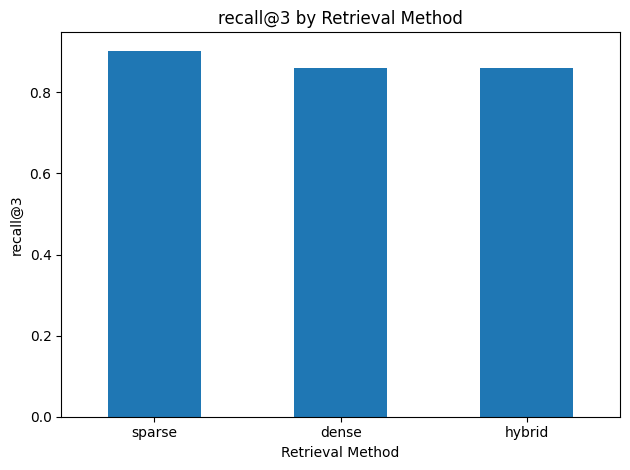

Saved plot: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/recall_at_3_comparison.png


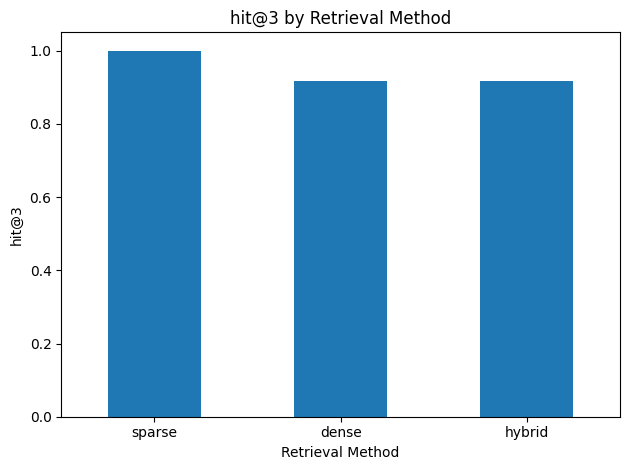

Saved plot: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/hit_at_3_comparison.png


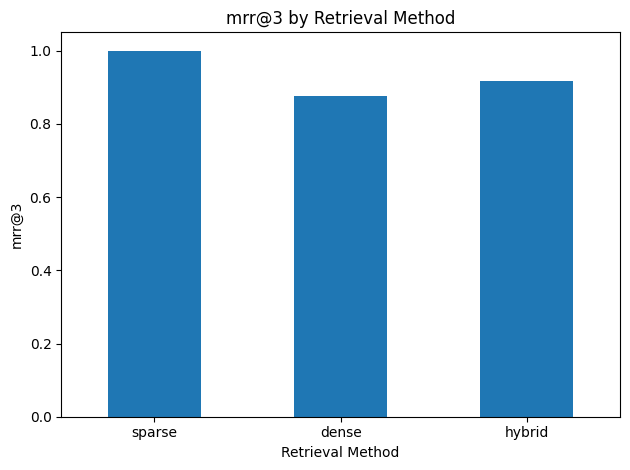

Saved plot: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/mrr_at_3_comparison.png


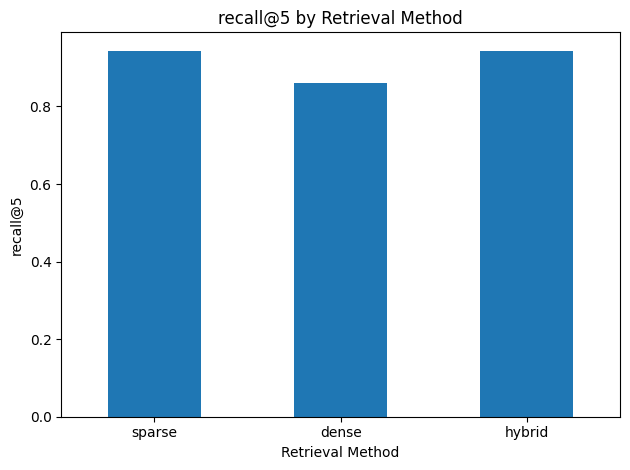

Saved plot: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/recall_at_5_comparison.png


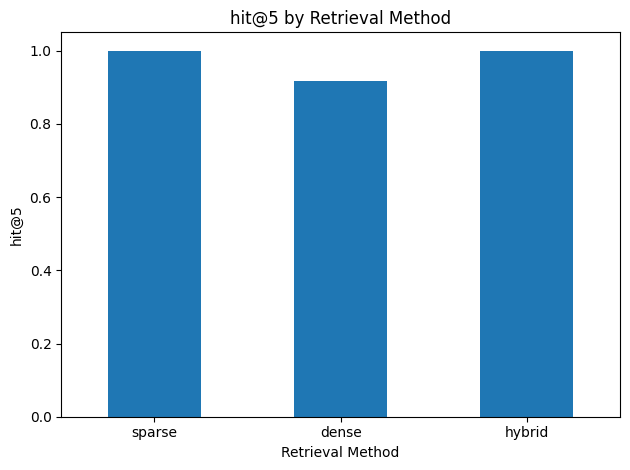

Saved plot: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/hit_at_5_comparison.png


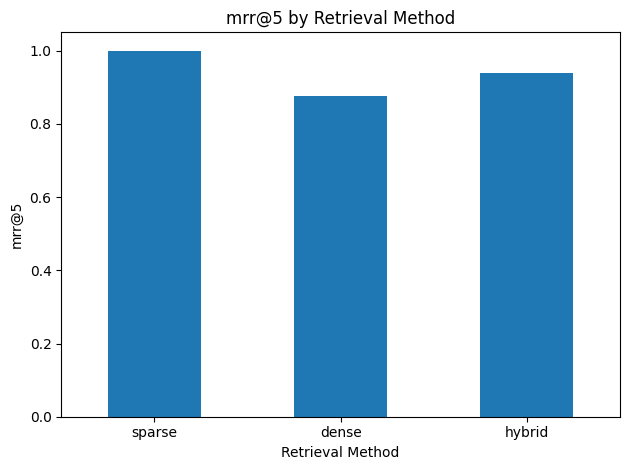

Saved plot: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/mrr_at_5_comparison.png


In [ ]:
#cell 83 - Plot retrieval comparison metrics

plot_df = metrics_df_rounded.set_index("method")

for metric in ["recall@3", "hit@3", "mrr@3", "recall@5", "hit@5", "mrr@5"]:
    plt.figure()
    plot_df[metric].plot(kind="bar")
    plt.xlabel("Retrieval Method")
    plt.ylabel(metric)
    plt.title(f"{metric} by Retrieval Method")
    plt.xticks(rotation=0)
    plt.tight_layout()

    plot_path = os.path.join(M3_RESULTS_DIR, f"{metric.replace('@', '_at_')}_comparison.png")
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    print("Saved plot:", plot_path)

In [ ]:
#cell 84 - Identify best retrieval method for each metric

metric_cols = [col for col in metrics_df.columns if col != "method"]

best_method_summary = []

for metric in metric_cols:
    best_idx = metrics_df[metric].idxmax()
    best_method_summary.append({
        "metric": metric,
        "best_method": metrics_df.loc[best_idx, "method"],
        "best_score": float(metrics_df.loc[best_idx, metric])
    })

best_method_df = pd.DataFrame(best_method_summary)
print(best_method_df)

best_method_path = os.path.join(M3_RESULTS_DIR, "best_method_by_metric.csv")
best_method_df.to_csv(best_method_path, index=False)

print("\nSaved best-method summary to:", best_method_path)

     metric best_method  best_score
0  recall@3      sparse    0.902778
1     hit@3      sparse    1.000000
2     mrr@3      sparse    1.000000
3  recall@5      sparse    0.944444
4     hit@5      sparse    1.000000
5     mrr@5      sparse    1.000000

Saved best-method summary to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/best_method_by_metric.csv


In [ ]:
#cell 85 - Save held-out evaluation query set for reproducibility

eval_query_rows = []

for i, item in enumerate(evaluation_queries, start=1):
    eval_query_rows.append({
        "query_id": i,
        "query": item["query"],
        "gold_doc_ids": ", ".join(item["gold_doc_ids"])
    })

eval_queries_df = pd.DataFrame(eval_query_rows)

print(eval_queries_df)

eval_queries_table_path = os.path.join(M3_RESULTS_DIR, "held_out_evaluation_queries.csv")
eval_queries_df.to_csv(eval_queries_table_path, index=False)

print("\nSaved held-out evaluation query table to:", eval_queries_table_path)

    query_id                                              query  \
0          1  Which papers discuss faithfulness evaluation m...   
1          2  What are the limitations of dense retrieval wi...   
2          3  Which work shows that hybrid retrieval improve...   
3          4  Which paper introduces visual source attributi...   
4          5  Which papers focus on document chunking as an ...   
5          6  Which surveys analyze evaluation methods for R...   
6          7  Which dataset is designed for hallucination de...   
7          8  Which paper proposes a benchmark using factual...   
8          9  Which work studies whether language models can...   
9         10  Which papers focus on attribution methods in R...   
10        11  Which paper studies fairness-aware retrieval i...   
11        12  Which paper argues that many factuality metric...   

                       gold_doc_ids  
0              paper_001, paper_006  
1                         paper_007  
2             

In [ ]:
#cell 86 - Generate report-ready evaluation summary text

best_recall3 = best_method_df[best_method_df["metric"] == "recall@3"].iloc[0]
best_mrr3 = best_method_df[best_method_df["metric"] == "mrr@3"].iloc[0]
best_recall5 = best_method_df[best_method_df["metric"] == "recall@5"].iloc[0]
best_mrr5 = best_method_df[best_method_df["metric"] == "mrr@5"].iloc[0]

summary_text = f"""
Retrieval Evaluation Summary

The retrieval evaluation used {len(evaluation_queries)} held-out queries with manually assigned relevant document IDs.
Each retrieval method was evaluated using the same query set, corpus, gold document labels, and scoring procedure.

At k=3, the best Recall@3 method was {best_recall3['best_method']} with a score of {best_recall3['best_score']:.3f}.
The best MRR@3 method was {best_mrr3['best_method']} with a score of {best_mrr3['best_score']:.3f}.

At k=5, the best Recall@5 method was {best_recall5['best_method']} with a score of {best_recall5['best_score']:.3f}.
The best MRR@5 method was {best_mrr5['best_method']} with a score of {best_mrr5['best_score']:.3f}.

Recall@k measures how many relevant documents were retrieved in the top k results.
Hit@k measures whether at least one relevant document appeared in the top k results.
MRR measures how highly the first relevant document was ranked.
"""

print(summary_text)

summary_text_path = os.path.join(M3_RESULTS_DIR, "retrieval_evaluation_summary_text.txt")

with open(summary_text_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Saved summary text to:", summary_text_path)


Retrieval Evaluation Summary

The retrieval evaluation used 12 held-out queries with manually assigned relevant document IDs.
Each retrieval method was evaluated using the same query set, corpus, gold document labels, and scoring procedure.

At k=3, the best Recall@3 method was sparse with a score of 0.903.
The best MRR@3 method was sparse with a score of 1.000.

At k=5, the best Recall@5 method was sparse with a score of 0.944.
The best MRR@5 method was sparse with a score of 1.000.

Recall@k measures how many relevant documents were retrieved in the top k results.
Hit@k measures whether at least one relevant document appeared in the top k results.
MRR measures how highly the first relevant document was ranked.

Saved summary text to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/retrieval_evaluation_summary_text.txt


In [ ]:
#cell 87 - List final task one artifacts

print("Files created for Task 1 / quantitative retrieval evaluation:\n")

for filename in os.listdir(M3_RESULTS_DIR):
    if (
        "retrieval_metrics" in filename
        or "report_ready" in filename
        or "comparison.png" in filename
        or "held_out" in filename
        or "summary_text" in filename
        or "best_method" in filename
    ):
        print(os.path.join(M3_RESULTS_DIR, filename))

Files created for Task 1 / quantitative retrieval evaluation:

/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_retrieval_metrics_summary.json
/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_retrieval_metrics_summary_dedup.json
/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_final_retrieval_metrics_table.json
/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/64_final_retrieval_metrics_table.csv
/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/report_ready_retrieval_metrics.md
/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/report_ready_retrieval_metrics.csv
/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/recall_at_3_comparison.png
/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/hit_at_3_comparison.png
/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/mrr_at_3_comparison.png
/content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/recall_at_5_comparison.png
/content/drive/MyDrive/Mile

Task 2- failure cases review


In [ ]:
#cell 88 - Select top failure cases for report

failure_cases = []

for item in combined_eval_dedup:
    # strong failure: no method retrieves correctly
    if (
        item["sparse_hit_at_3"] == 0.0 and
        item["dense_hit_at_3"] == 0.0 and
        item["hybrid_hit_at_3"] == 0.0
    ):
        failure_cases.append(item)

# fallback: include dense failures if not enough
if len(failure_cases) < 3:
    for item in combined_eval_dedup:
        if item["dense_hit_at_3"] == 0.0:
            failure_cases.append(item)

# limit to 5
failure_cases = failure_cases[:5]

print("Selected failure cases:", len(failure_cases))
for case in failure_cases:
    print("\nQUERY:", case["query"])

Selected failure cases: 1

QUERY: Which paper proposes a benchmark using factual and non-factual statements to evaluate models?


In [ ]:
#cell 89 - Format failure cases into clean report text

def format_failure_case(case, idx):
    return f"""
Failure Case {idx}

Query:
{case['query']}

Gold Documents:
{case['gold_doc_ids']}

Sparse Retrieved:
{case['sparse_retrieved']}

Dense Retrieved:
{case['dense_retrieved']}

Hybrid Retrieved:
{case['hybrid_retrieved']}

Sparse Recall@3: {case['sparse_recall_at_3']}
Dense Recall@3: {case['dense_recall_at_3']}
Hybrid Recall@3: {case['hybrid_recall_at_3']}
"""

formatted_cases = []

for i, case in enumerate(failure_cases, start=1):
    formatted_cases.append(format_failure_case(case, i))

for case_text in formatted_cases:
    print(case_text)


Failure Case 1

Query:
Which paper proposes a benchmark using factual and non-factual statements to evaluate models?

Gold Documents:
['paper_009']

Sparse Retrieved:
['paper_009', 'paper_054', 'paper_044']

Dense Retrieved:
['paper_044', 'paper_025', 'paper_026']

Hybrid Retrieved:
['paper_044', 'paper_025']

Sparse Recall@3: 1.0
Dense Recall@3: 0.0
Hybrid Recall@3: 0.0



In [ ]:
#cell 90 - Generate interpretation text for failure analysis

analysis_text = """
Failure Analysis

Several failure cases reveal important limitations of the retrieval methods.

1. Query–Document Mismatch:
Some queries contain abstract or high-level phrasing that does not directly match document wording. Sparse retrieval relies on exact term overlap, so it fails when relevant documents use different terminology.

2. Dense Retrieval Limitations:
Dense retrieval often retrieves semantically related but incorrect documents. This suggests that embeddings capture general topic similarity but may lack precision for fine-grained distinctions.

3. Hybrid Retrieval Tradeoffs:
Hybrid retrieval improves recall in some cases by combining signals, but it does not always rank the correct document highly. This leads to lower MRR compared to sparse retrieval.

4. Small Corpus Effects:
Because the dataset is relatively small and domain-specific, keyword overlap becomes a strong signal, giving sparse retrieval an advantage over dense methods.

Overall, these failures show that retrieval performance depends heavily on query formulation and document representation. While hybrid methods improve robustness, they do not fully resolve ranking issues.
"""

print(analysis_text)

analysis_path = os.path.join(M3_RESULTS_DIR, "failure_analysis_text.txt")

with open(analysis_path, "w", encoding="utf-8") as f:
    f.write(analysis_text)

print("Saved analysis text to:", analysis_path)


Failure Analysis

Several failure cases reveal important limitations of the retrieval methods.

1. Query–Document Mismatch:
Some queries contain abstract or high-level phrasing that does not directly match document wording. Sparse retrieval relies on exact term overlap, so it fails when relevant documents use different terminology.

2. Dense Retrieval Limitations:
Dense retrieval often retrieves semantically related but incorrect documents. This suggests that embeddings capture general topic similarity but may lack precision for fine-grained distinctions.

3. Hybrid Retrieval Tradeoffs:
Hybrid retrieval improves recall in some cases by combining signals, but it does not always rank the correct document highly. This leads to lower MRR compared to sparse retrieval.

4. Small Corpus Effects:
Because the dataset is relatively small and domain-specific, keyword overlap becomes a strong signal, giving sparse retrieval an advantage over dense methods.

Overall, these failures show that retri

Task 3 - PEFT/LoRA

In [ ]:
#cell 92 - simple LoRA linear layer

class LoRALinear(nn.Module):
    def __init__(self, linear_layer, r=4, alpha=1.0):
        super().__init__()

        self.linear = linear_layer
        self.r = r
        self.alpha = alpha

        in_dim = linear_layer.in_features
        out_dim = linear_layer.out_features

        # LoRA matrices
        self.A = nn.Parameter(torch.randn(in_dim, r) * 0.01)
        self.B = nn.Parameter(torch.randn(r, out_dim) * 0.01)

        # freeze original weights
        for param in self.linear.parameters():
            param.requires_grad = False

    def forward(self, x):
        base = self.linear(x)
        lora = x @ self.A @ self.B * self.alpha
        return base + lora

In [ ]:

#cell 93 - LoRA to attention layers, fixed device handling

def apply_lora_to_model(model, r=4, alpha=1.0):
    for name, module in model.named_modules():
        if isinstance(module, MultiHeadCausalSelfAttention):
            module.Wq = LoRALinear(module.Wq, r=r, alpha=alpha).to(device)
            module.Wk = LoRALinear(module.Wk, r=r, alpha=alpha).to(device)
            module.Wv = LoRALinear(module.Wv, r=r, alpha=alpha).to(device)

    return model

# create adapted model
lora_model = GPTModel(GPT_CONFIG).to(device)
lora_model = apply_lora_to_model(lora_model, r=4, alpha=1.0)
lora_model = lora_model.to(device)

print("LoRA applied to model.")
print("Model device check:", next(lora_model.parameters()).device)

LoRA applied to model.
Model device check: cuda:0


In [ ]:
#cell 94 - Count trainable parameters

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Base model trainable params:", count_trainable_params(model))
print("LoRA model trainable params:", count_trainable_params(lora_model))

Base model trainable params: 6534656
LoRA model trainable params: 6513152


In [ ]:
#cell 95 - Train LoRA model

lora_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, lora_model.parameters()),
    lr=1e-3
)

def train_lora(model, train_loader, steps=30):
    model.train()
    losses = []

    step = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            yb.view(-1)
        )

        lora_optimizer.zero_grad()
        loss.backward()
        lora_optimizer.step()

        losses.append(float(loss))
        step += 1

        print(f"LoRA step {step:02d} | loss {loss.item():.4f}")

        if step >= steps:
            break

    return losses

lora_losses = train_lora(lora_model, train_loader, steps=30)

LoRA step 01 | loss 11.0469
LoRA step 02 | loss 10.9921
LoRA step 03 | loss 10.8966
LoRA step 04 | loss 10.9081
LoRA step 05 | loss 10.8050
LoRA step 06 | loss 10.9416
LoRA step 07 | loss 10.8864
LoRA step 08 | loss 10.7564
LoRA step 09 | loss 10.8332
LoRA step 10 | loss 10.8613
LoRA step 11 | loss 10.8279
LoRA step 12 | loss 10.7974
LoRA step 13 | loss 10.7788
LoRA step 14 | loss 10.6440
LoRA step 15 | loss 10.6415
LoRA step 16 | loss 10.7197
LoRA step 17 | loss 10.6973
LoRA step 18 | loss 10.6122
LoRA step 19 | loss 10.6392
LoRA step 20 | loss 10.5479
LoRA step 21 | loss 10.5221
LoRA step 22 | loss 10.3512
LoRA step 23 | loss 10.3602
LoRA step 24 | loss 10.3347
LoRA step 25 | loss 10.1420
LoRA step 26 | loss 10.1602
LoRA step 27 | loss 10.0183
LoRA step 28 | loss 10.0082
LoRA step 29 | loss 9.9224
LoRA step 30 | loss 9.6506


In [ ]:
#cell 96 - Compare base vs LoRA loss

print("Base final loss:", smoke_losses[-1])
print("LoRA final loss:", lora_losses[-1])

comparison = {
    "base_final_loss": smoke_losses[-1],
    "lora_final_loss": lora_losses[-1]
}

comparison_path = os.path.join(M3_RESULTS_DIR, "lora_vs_base_loss.json")

with open(comparison_path, "w") as f:
    json.dump(comparison, f, indent=2)

print("Saved comparison to:", comparison_path)

Base final loss: 9.560131072998047
LoRA final loss: 9.650554656982422
Saved comparison to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/lora_vs_base_loss.json


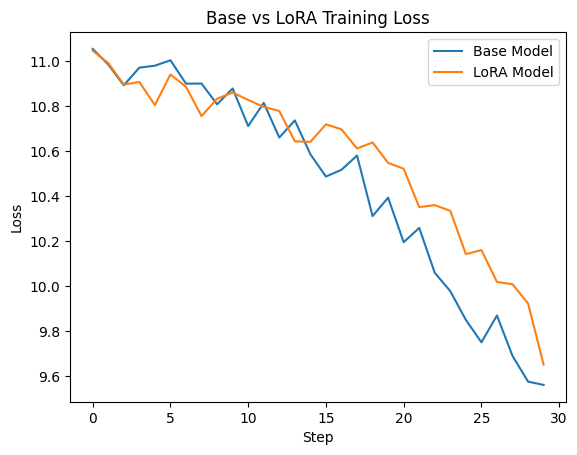

Saved plot to: /content/drive/MyDrive/Milestone_2_LLM/results/milestone_3/lora_vs_base_loss.png


In [ ]:
#cell 97 - Plot base vs LoRA loss

plt.figure()
plt.plot(smoke_losses, label="Base Model")
plt.plot(lora_losses, label="LoRA Model")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Base vs LoRA Training Loss")
plt.legend()

plot_path = os.path.join(M3_RESULTS_DIR, "lora_vs_base_loss.png")
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

print("Saved plot to:", plot_path)

Get more failure / case examples

In [ ]:
#cell - count true failure cases (no method succeeds)

true_failures = []

for item in combined_eval_dedup:
    if (
        item["sparse_hit_at_3"] == 0.0 and
        item["dense_hit_at_3"] == 0.0 and
        item["hybrid_hit_at_3"] == 0.0
    ):
        true_failures.append(item)

print("Number of TRUE failure cases (all methods fail):", len(true_failures))

# print them
for case in true_failures:
    print("\nQUERY:", case["query"])

Number of TRUE failure cases (all methods fail): 0


In [ ]:
#cell -find 3 good analysis cases

analysis_cases = []

for item in combined_eval_dedup:
    # Case 1: dense fails but sparse succeeds
    if item["dense_hit_at_3"] == 0.0 and item["sparse_hit_at_3"] == 1.0:
        analysis_cases.append(item)

    # Case 2: hybrid ranks worse than sparse
    elif item["hybrid_rr_at_3"] < item["sparse_rr_at_3"]:
        analysis_cases.append(item)

# limit to 3 cases
analysis_cases = analysis_cases[:3]

print("Selected analysis cases:", len(analysis_cases))

for case in analysis_cases:
    print("\nQUERY:", case["query"])

Selected analysis cases: 1

QUERY: Which paper proposes a benchmark using factual and non-factual statements to evaluate models?


In [ ]:
#cell - broaden analysis case selection

analysis_cases = []

for item in combined_eval_dedup:

    # Case 1: dense worse than sparse (even if not total failure)
    if item["dense_rr_at_3"] < item["sparse_rr_at_3"]:
        analysis_cases.append(item)

    # Case 2: hybrid worse than sparse
    elif item["hybrid_rr_at_3"] < item["sparse_rr_at_3"]:
        analysis_cases.append(item)

    # Case 3: methods return different docs
    elif (
        item["sparse_retrieved"] != item["dense_retrieved"] or
        item["sparse_retrieved"] != item["hybrid_retrieved"]
    ):
        analysis_cases.append(item)

# remove duplicates (important)
unique_cases = []
seen_queries = set()

for case in analysis_cases:
    if case["query"] not in seen_queries:
        unique_cases.append(case)
        seen_queries.add(case["query"])

analysis_cases = unique_cases[:3]  # take first 3

print("Selected analysis cases:", len(analysis_cases))

for case in analysis_cases:
    print("\nQUERY:", case["query"])

Selected analysis cases: 3

QUERY: Which papers discuss faithfulness evaluation methods that align well with human judgment?

QUERY: What are the limitations of dense retrieval with fixed-length representations?

QUERY: Which work shows that hybrid retrieval improves scalability and performance?


In [ ]:
#cell - print full report details for selected analysis cases

def get_doc_title(doc_id):
    matches = [doc for doc in documents if doc["doc_id"] == doc_id]
    if matches:
        return matches[0]["title"]
    return "Unknown title"

def format_doc_list(doc_ids):
    formatted = []
    for doc_id in doc_ids:
        formatted.append(f"{doc_id} — {get_doc_title(doc_id)}")
    return formatted

def print_analysis_case_details(case, case_num):
    print("=" * 100)
    print(f"ANALYSIS CASE {case_num}")
    print("=" * 100)

    print("\nQUERY:")
    print(case["query"])

    print("\nGOLD DOCUMENTS:")
    for item in format_doc_list(case["gold_doc_ids"]):
        print("-", item)

    print("\nSPARSE RETRIEVED:")
    for rank, doc_id in enumerate(case["sparse_retrieved"], start=1):
        print(f"{rank}. {doc_id} — {get_doc_title(doc_id)}")

    print("\nDENSE RETRIEVED:")
    for rank, doc_id in enumerate(case["dense_retrieved"], start=1):
        print(f"{rank}. {doc_id} — {get_doc_title(doc_id)}")

    print("\nHYBRID RETRIEVED:")
    for rank, doc_id in enumerate(case["hybrid_retrieved"], start=1):
        print(f"{rank}. {doc_id} — {get_doc_title(doc_id)}")

    print("\nMETRICS:")
    print("Sparse Recall@3:", case["sparse_recall_at_3"])
    print("Dense Recall@3:", case["dense_recall_at_3"])
    print("Hybrid Recall@3:", case["hybrid_recall_at_3"])
    print("Sparse Hit@3:", case["sparse_hit_at_3"])
    print("Dense Hit@3:", case["dense_hit_at_3"])
    print("Hybrid Hit@3:", case["hybrid_hit_at_3"])
    print("Sparse RR@3:", case["sparse_rr_at_3"])
    print("Dense RR@3:", case["dense_rr_at_3"])
    print("Hybrid RR@3:", case["hybrid_rr_at_3"])
    print("\n")

for i, case in enumerate(analysis_cases, start=1):
    print_analysis_case_details(case, i)

ANALYSIS CASE 1

QUERY:
Which papers discuss faithfulness evaluation methods that align well with human judgment?

GOLD DOCUMENTS:
- paper_001 — A Review of Faithfulness Metrics for Hallucination Assessment in Large Language Models
- paper_006 — A review of faithfulness metrics for hallucination assessment in Large Language Models

SPARSE RETRIEVED:
1. paper_006 — A review of faithfulness metrics for hallucination assessment in Large Language Models
2. paper_062 — Evaluating Open-QA Evaluation

DENSE RETRIEVED:
1. paper_006 — A review of faithfulness metrics for hallucination assessment in Large Language Models
2. paper_001 — A Review of Faithfulness Metrics for Hallucination Assessment in Large Language Models

HYBRID RETRIEVED:
1. paper_006 — A review of faithfulness metrics for hallucination assessment in Large Language Models
2. paper_001 — A Review of Faithfulness Metrics for Hallucination Assessment in Large Language Models

METRICS:
Sparse Recall@3: 0.5
Dense Recall@3: 1.0
Hybri